In [ ]:
import pandas as pd

AHOJ_PATH = '/home/skrhakv/CryptoBench/data/A-filter-ahojdb/all_holo'

file = AHOJ_PATH + '/holo_only_data/pairs.csv'
first_line = pd.read_csv(file, nrows=10)
print(first_line)

   Unnamed: 0 structure pocket   query_POI POI_type role apoholo_assignment  \
0           0      3kr4     p1  K_BES_1003      lig    Q                  H   
1           0      3kun     p1   B_HEM_139      lig    Q                  H   
2           0      5t67     p1   A_SAH_502      lig    Q                  H   
3           0      3kr6     p1   A_FFQ_500      lig    Q                  H   
4           0      3kpz     p1   A_ZNE_525      lig    Q                  H   
5           0      3kr4     p1  I_BES_1003      lig    Q                  H   
6           0      3krq     p1   A_3TR_608      lig    Q                  H   
7           0      3krk     p1   B_ACD_700      lig    Q                  H   
8           0      3kmc     p1   A_INN_485      lig    Q                  H   
9           0      3kmf     p1   E_HEM_542      lig    Q                  H   

   #resis1  #resis2  #resis5  ...  aln_len  pocket_rms  pocket_len  \
0       20       20       20  ...      NaN         NaN      

In [2]:
disprot_file = '/home/skrhakv/CryptoBench/data/disprot-data.tsv'
disprot_df = pd.read_csv(disprot_file, sep='\t')
unique_acc1 = disprot_df['acc'].unique()
print(unique_acc1)


['P03265' 'P49913' 'P03045' ... 'P02647' 'Q13613' 'Q9UJY1']


In [ ]:
ahojDB_file = AHOJ_PATH + '/pairs.csv'
ahojDB_df = pd.read_csv(ahojDB_file)
ahojDB_df['protein_id'] = ahojDB_df['structure'] + '_' + ahojDB_df['chains3']
unique_acc2 = ahojDB_df['UNPs'].unique()
print(unique_acc2)

def process_binding_site(binding_site):
    if pd.isna(binding_site):
        return None
    binding_site = binding_site.strip().split(' ')
    binding_site_residues = [int(i.replace(')', '')) for i in binding_site[-2].split('+')]
    return binding_site_residues


/tmp/slurm.137625/ipykernel_656365/964568982.py:2: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  ahojDB_df = pd.read_csv(ahojDB_file)


['Q8IL11' 'O00214' 'Q9NAV8' ... 'Q9N0F3' 'Q96AZ6' 'Q96X16']


In [4]:
intersection = set(unique_acc1) & set(unique_acc2)
print(intersection)
print(len(intersection))

{'P10275', 'P49327', 'O60568', 'P20061', 'P61587', 'O33599', 'Q13363', 'Q01782', 'Q08826', 'P55042', 'P35520', 'Q9QXN5', 'Q9H5I1', 'P54132', 'Q96RS0', 'O76074', 'Q92905', 'Q14191', 'Q92731', 'P04183', 'Q91ZW2', 'P08631', 'P30771', 'Q15418', 'A0A109NYM0', 'Q96SD1', 'P78362', 'P30291', 'O96028', 'E9AE57', 'O23813', 'Q9NXG6', 'Q4QCD2', 'Q8NER1', 'P07598', 'Q9R0M6', 'P18212', 'A1L1Q4', 'O50008', 'Q3UKX1', 'Q8LGG8', 'Q9UBK8', 'Q9T0N8', 'P40999', 'Q86MV5', 'P27361', 'O60825', 'Q8WVQ1', 'P00004', 'O14727', 'P07342', 'O43776', 'Q12051', 'Q16647', 'P38038', 'P00392', 'O00834', 'P01111', 'P16278', 'Q9Z2F5', 'P47895', 'P15309', 'Q9NRN7', 'Q7RTP6', 'P55789', 'Q8ZKB0', 'P11233', 'P05451', 'Q9UPP1', 'P10686', 'P08253', 'F1QCV2', 'Q9MAA7', 'Q8VDP3', 'O15054', 'P0DMV9', 'Q8I295', 'P33371', 'P26332', 'P23677', 'O75936', 'Q96EP1', 'P52874', 'Q9AXT8', 'P24348', 'Q8WQX9', 'P62330', 'O04147', 'P15436', 'Q7RTN6', 'P16869', 'P07902', 'Q9K169', 'P44654', 'D0AB09', 'Q16222', 'Q922S8', 'Q13501', 'A6QHR2', 'Q96Q

In [ ]:
# take intersection, loop over the two DFs, get all the binding sites and disordered regions from each uniprot
def extract_disordered_binding_sites(ahojDB_df, disprot_df, intersection):
    """Extract binding sites and disordered regions for proteins in the intersection of ahojDB and DisProt."""
    ahoj_uniprot_binding_sites = {}
    disprot_uniprot_disordered_regions = {}
    for unp in intersection:
        # get binding sites from ahoj
        ahoj_binding_sites = ahojDB_df[ahojDB_df['UNPs'] == unp]['alphafold_pocket_selection'].tolist()
        for binding_site in ahoj_binding_sites:
            if unp not in ahoj_uniprot_binding_sites:
                ahoj_uniprot_binding_sites[unp] = []
            processed_site = process_binding_site(binding_site)
            ahoj_uniprot_binding_sites[unp].append(processed_site)

        # get list of pairs (start, end) indicating disordered regions from disprot
        disprot_disordered_regions = disprot_df[(disprot_df['acc'] == unp) & ((disprot_df['term_name'] == 'disorder') | (disprot_df['term_name'] == 'disorder to order'))][['start', 'end']].values.tolist() # (disprot_df['term_name'] == 'disorder to order') has no effect
        disprot_uniprot_disordered_regions[unp] = disprot_disordered_regions 
    return ahoj_uniprot_binding_sites, disprot_uniprot_disordered_regions

def count_disordered_binding_sites(ahoj_uniprot_binding_sites, disprot_uniprot_disordered_regions, intersection):
    """Count disordered binding sites."""
    number_of_disordered_binding_sequences = 0
    for unp in intersection:
        for binding_site in ahoj_uniprot_binding_sites[unp]:
            for disordered_region in disprot_uniprot_disordered_regions[unp]:
                number_of_disordered_binding_residues = 0
                for residue in binding_site:
                    if disordered_region[0] <= residue <= disordered_region[1]:
                        number_of_disordered_binding_residues += 1
                if number_of_disordered_binding_residues / len(binding_site) >= 0.9:
                    number_of_disordered_binding_sequences += 1
                    break
    print(f'Number of disordered binding sequences: {number_of_disordered_binding_sequences}')

ahoj_uniprot_binding_sites, disprot_uniprot_disordered_regions = extract_disordered_binding_sites(ahojDB_df, disprot_df, intersection)
count_disordered_binding_sites(ahoj_uniprot_binding_sites, disprot_uniprot_disordered_regions, intersection)

### Different thresholds
It depends on selecting the threshold of `number_of_disordered_binding_residues / len(binding_site)` how many suitable examples we retrieve:
1. 0.1 - 101 examples
2. 0.2 - 74 examples
3. 0.25 - 44 examples
4. 0.5 - 22 examples
5. 0.9 - 22 examples

## Checkout SoftDis database
At ISCB, there was a talk about `soft disorder` denoting residues which are missing in some X-ray structures but are apparent in others. This information was curated into a database called SoftDis. Let's find the intersection of the SoftDis database with AHoJ-DB.

In [3]:
from datasets import load_dataset

dataset = load_dataset("CQSB/SoftDis")

In [4]:
import numpy as np

def binarize(sample):
    sample["soft_disorder_class"] = (
        sample["soft_disorder_frequency"] > 0
    ).astype(np.int64)
    return sample

dataset.set_format(type="numpy")  # convert items to numpy objects
dataset = dataset.map(binarize)   # apply function to all entries


In [5]:
count_disordered_binding_sites = 0
softly_disordered_binding_sites = {}

for soft_dis_protein in dataset['train']:
    protein_id = soft_dis_protein['id']
    sequence = soft_dis_protein['sequence']
    soft_disorder_mask = soft_dis_protein['soft_disorder_class']
    ahoj_binding_sites = ahojDB_df[ahojDB_df['protein_id'] == protein_id]['label_seq_pdb_pocket_selection'].tolist()
    binding_mask = np.zeros(len(sequence), dtype=bool)
    if len(ahoj_binding_sites) == 0:
        continue
    # loop over all binding sites for this protein
    for binding_site in ahoj_binding_sites:
        processed_site = process_binding_site(binding_site)
        # the binding site residues are 1-based, convert to 0-based
        processed_site = [residue - 1 for residue in processed_site]
        if max(processed_site) >= len(sequence):
            print(f'Binding site {processed_site} exceeds sequence length {len(sequence)} for protein {protein_id}. Skipping.')
            break

        # get binding mask for this binding site
        this_binding_mask = np.zeros(len(sequence), dtype=bool)
        for residue in processed_site:
            this_binding_mask[residue] = True

        # get overlap percentage between soft disorder mask and binding mask, if any overlap then save the binding site
        binding_disorder_overlap_percentage = sum(soft_disorder_mask & this_binding_mask) / len(processed_site)
        if binding_disorder_overlap_percentage > 0:
            if protein_id not in softly_disordered_binding_sites:
                softly_disordered_binding_sites[protein_id] = []
            softly_disordered_binding_sites[protein_id].append((this_binding_mask, binding_disorder_overlap_percentage, sequence))
    
    print(f'count_disordered_binding_sites: {len(softly_disordered_binding_sites)} at protein {protein_id}')

count_disordered_binding_sites: 1 at protein 11as_A
count_disordered_binding_sites: 2 at protein 13pk_A
count_disordered_binding_sites: 2 at protein 155c_A
count_disordered_binding_sites: 2 at protein 1a0t_Q
count_disordered_binding_sites: 3 at protein 1a25_B
count_disordered_binding_sites: 4 at protein 1a27_A
count_disordered_binding_sites: 5 at protein 1a3w_A
count_disordered_binding_sites: 6 at protein 1a4h_A
count_disordered_binding_sites: 7 at protein 1a54_A
count_disordered_binding_sites: 8 at protein 1a59_A
count_disordered_binding_sites: 8 at protein 1a5i_A
count_disordered_binding_sites: 8 at protein 1a5z_A
count_disordered_binding_sites: 9 at protein 1a6e_A
count_disordered_binding_sites: 10 at protein 1a6e_B
count_disordered_binding_sites: 11 at protein 1a6k_A
count_disordered_binding_sites: 12 at protein 1a80_A
count_disordered_binding_sites: 13 at protein 1a8p_A
count_disordered_binding_sites: 14 at protein 1a8t_A
count_disordered_binding_sites: 15 at protein 1a9w_F
count_

In [ ]:
import pickle
with open(AHOJ_PATH + '/softly_disordered_binding_sites.pkl', 'wb') as f:
    pickle.dump(softly_disordered_binding_sites, f)

In [3]:
import pickle 
with open('softly_disordered_binding_sites.pkl', 'rb') as f:
    softly_disordered_binding_sites = pickle.load(f)


In [6]:
softly_disordered_binding_sites['11as_A']

[(array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
          True, False,  True, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False,  True,
         False,  True, False, False,  True, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
          True, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False,  True, False,
          True, False, False, False, False, False, False, False,

In [19]:
MIN_OVERLAP = 0.8
num_proteins_with_overlap = sum(
    any(overlap > MIN_OVERLAP for _, overlap, _ in sites)
    for sites in softly_disordered_binding_sites.values()
)
print(f'Number of proteins with at least one pocket overlap > {MIN_OVERLAP}: {num_proteins_with_overlap}')

Number of proteins with at least one pocket overlap > 0.8: 102


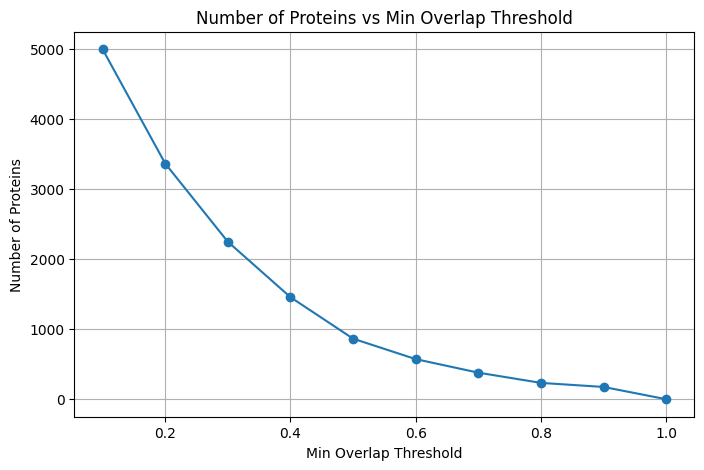

In [7]:
import numpy as np

import matplotlib.pyplot as plt

thresholds = np.arange(0.1, 1.01, 0.1)
counts = [
    sum(any(overlap > t for _, overlap, _ in sites)
        for sites in softly_disordered_binding_sites.values())
    for t in thresholds
]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, counts, marker='o')
plt.xlabel('Min Overlap Threshold')
plt.ylabel('Number of Proteins')
plt.title('Number of Proteins vs Min Overlap Threshold')
plt.grid(True)
plt.show()